### 3.4.2. Quadratic Programming (QP)

$$
\begin{aligned}
\min_{\mathbf{x}}\quad & \tfrac12 \mathbf{x}^\top P \mathbf{x} + \mathbf{q}^\top \mathbf{x} \\
\text{subject to}\quad & G\mathbf{x} \le \mathbf{h},\\
& A\mathbf{x} = \mathbf{b},
\end{aligned}
\qquad P \succeq 0.
$$

**Explanation:**

A quadratic program (QP) minimizes a convex quadratic objective over a polyhedron: the objective adds a curvature term $\tfrac12\mathbf{x}^\top P\mathbf{x}$ to the linear cost of a [linear program](./01_linear_programming.ipynb), while the feasible set stays a polyhedron of affine inequalities and equalities. Positive semidefiniteness of $P$ is the convexity requirement, so any local solution is global. Unlike the unconstrained quadratic minimizer $P\mathbf{x}=-\mathbf{q}$, a QP solution generally lies on the boundary where some constraints are active, and is characterized by the KKT conditions and located by [active-set](../09_Algorithms/31_active_set_methods.ipynb) or interior-point solvers. Adding quadratic *constraints* leads to the [QCQP](./03_quadratically_constrained_quadratic_programming.ipynb) treated next.

**Intuition:**

The elliptical cost contours press against the polyhedral feasible region; the minimizer is where the lowest contour still touches the region.

![Quadratic program geometry](../../Figures/030306_bv_fig_4_5_quadratic_program_geometry.jpeg)

**Numerical Example:**

$$
\min_{x_1,x_2}\; \tfrac12\big(x_1^2 + x_2^2\big) - x_1 - 2x_2
\quad\text{subject to}\quad x_1 + x_2 \le 2.
$$

Here $P=I$, $\mathbf{q}=(-1,-2)$. The unconstrained minimizer is $(1,2)$, but $1+2=3>2$ is infeasible, so the constraint is active. With multiplier $\mu\ge 0$ the KKT stationarity $\nabla f + \mu\nabla g = \mathbf 0$ gives
$$
(x_1-1) + \mu = 0,\quad (x_2-2) + \mu = 0,\quad x_1 + x_2 = 2,
$$
so $x_1 = 1-\mu$, $x_2 = 2-\mu$, and $3-2\mu = 2 \Rightarrow \mu = \tfrac12 \ge 0$. Thus
$$
\mathbf{x}^\star = \left(\tfrac12, \tfrac32\right),\qquad f^\star = -\tfrac{9}{4}.
$$

In [1]:
import sympy as sp

x_1, x_2, mu = sp.symbols("x_1 x_2 mu", real=True)
decision_variable = sp.Matrix([x_1, x_2])
objective = sp.Rational(1, 2)*(x_1**2 + x_2**2) - x_1 - 2*x_2
active_constraint = x_1 + x_2 - 2
lagrangian = objective + mu*active_constraint

stationarity = [sp.diff(lagrangian, variable) for variable in (x_1, x_2)]
solution = sp.solve(stationarity + [active_constraint], [x_1, x_2, mu], dict=True)[0]
minimizer = (solution[x_1], solution[x_2])
minimum_value = objective.subs(solution)

print("minimizer =", minimizer)
print("multiplier mu =", solution[mu], "(>= 0, constraint active)")
print("minimum value =", minimum_value)

minimizer = (1/2, 3/2)
multiplier mu = 1/2 (>= 0, constraint active)
minimum value = -9/4


**Equivalent casadi implementation:**

In [2]:
import casadi as ca

decision_variable = ca.SX.sym("x", 2)
objective = 0.5*(decision_variable[0]**2 + decision_variable[1]**2) - decision_variable[0] - 2*decision_variable[1]
constraint = decision_variable[0] + decision_variable[1]

solver = ca.qpsol("solver", "qpoases", {"x": decision_variable, "f": objective, "g": constraint},
                  {"printLevel": "none"})
solution = solver(ubg=2)

print("minimizer =", solution["x"])
print("minimum value =", float(solution["f"]))


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

minimizer = [0.5, 1.5]
minimum value = -

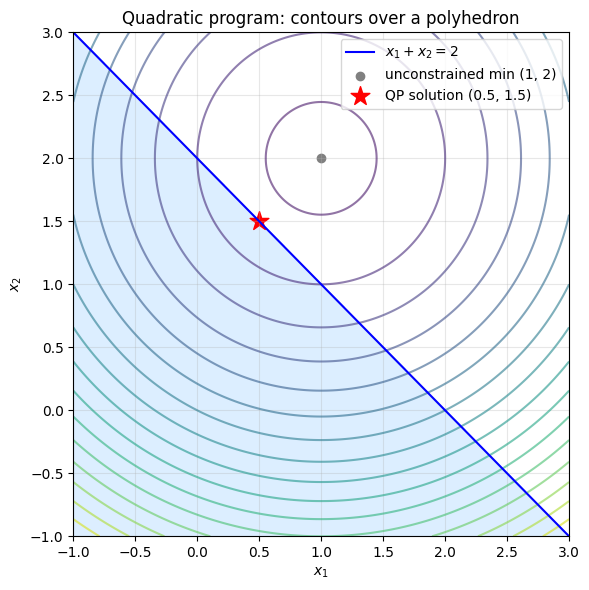

In [3]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-1, 3, 400)
mesh_x, mesh_y = np.meshgrid(grid, grid)
cost = 0.5*(mesh_x**2 + mesh_y**2) - mesh_x - 2*mesh_y

plt.figure(figsize=(6, 6))
plt.contour(mesh_x, mesh_y, cost, levels=20, alpha=0.6)
feasible = mesh_x + mesh_y <= 2
plt.contourf(mesh_x, mesh_y, feasible, levels=[0.5, 1.5], colors=["#8ec7ff"], alpha=0.3)
plt.plot(grid, 2 - grid, "b-", label="$x_1 + x_2 = 2$")
plt.scatter([1], [2], color="gray", marker="o", label="unconstrained min (1, 2)")
plt.scatter([0.5], [1.5], color="red", marker="*", s=200, label="QP solution (0.5, 1.5)")
plt.xlim(-1, 3); plt.ylim(-1, 3)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Quadratic program: contours over a polyhedron")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**References:**

[📘 Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.](https://web.stanford.edu/~boyd/cvxbook/)

---

[⬅️ Previous: Linear Programming (LP)](./01_linear_programming.ipynb) | [Next: Quadratically Constrained Quadratic Programming (QCQP) ➡️](./03_quadratically_constrained_quadratic_programming.ipynb)